# One-dimensional stochastic degradation model

In this part, we simulate and estimate a one-dimensional stochastic degradation model for machine health indices.

The model has the form

$$
S(t) = R(t) + T(t),
$$

where $T(t)$ is a deterministic trend and $R(t)$ is a random component. The random component is defined as

$$
R(t) = SC(t)R2(t),
$$

where $SC(t)$ is a time-varying scale function and $R2(t)$ is a stationary autoregressive process.

The goal of this section is to:
1. simulate data from the model,
2. estimate the trend and scale,
3. normalize the random component,
4. fit an AR model,
5. estimate the stability index $\alpha$ of the residual noise.

In [90]:
import importlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import simulation1d
import estimation1d

importlib.reload(simulation1d)
importlib.reload(estimation1d)

from simulation1d import simulate_1d_model
from estimation1d import estimate_1d_model, summarize_1d_estimation, estimate_1d_model_fixed_ar_order

## Simulation parameters

We use the same general parameter setting as in the reference methodology:

$$
N=2000,\quad \tau_1=N/3,\quad \tau_2=2N/3.
$$

The random component is generated from an AR(1) model with coefficient $\phi=0.5$. The scale function increases from 
$\sigma_1=1$ to $\sigma_4=25$, and the deterministic trend starts from $c_1=10$.

In [131]:
N = 2000
tau1 = N / 3
tau2 = 2 * N / 3

base_params = dict(
    N=N,
    tau1=tau1,
    tau2=tau2,
    phi=(0.5,),
    gamma=1.0,
    sigma1=1.0,
    sigma2=2.5,
    sigma3=5.0,
    sigma4=25.0,
    c1=10.0,
)

## Single trajectory simulation

First, we simulate one trajectory for $\alpha=1.9$. This corresponds to a non-Gaussian heavy-tailed noise distribution. We expect the signal to be relatively stable at the beginning and more volatile in the final degradation regime due to the increasing scale.

In [133]:
simulation = simulate_1d_model(
    **base_params,
    alpha=1.9,
    random_state=42,
)

simulation.keys()

dict_keys(['t', 'S', 'R', 'R2', 'R3', 'SC', 'T', 'scale_params', 'trend_params', 'params'])

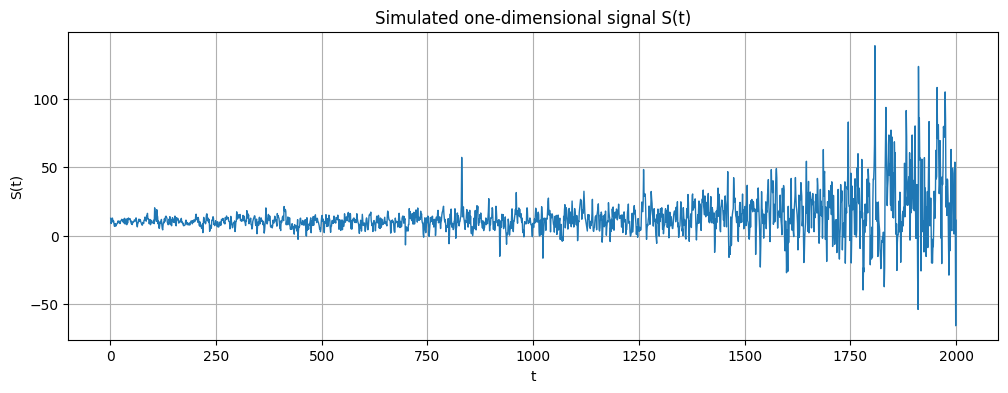

In [134]:
t = simulation["t"]

plt.figure(figsize=(12, 4))
plt.plot(t, simulation["S"], linewidth=1)
plt.title("Simulated one-dimensional signal S(t)")
plt.xlabel("t")
plt.ylabel("S(t)")
plt.grid(True)
plt.show()

The simulated signal shows three qualitative stages. In the initial part, the variability is relatively low. Later, both the trend and the scale increase. In the final regime, the signal becomes much more volatile, which reflects the accelerated degradation stage.

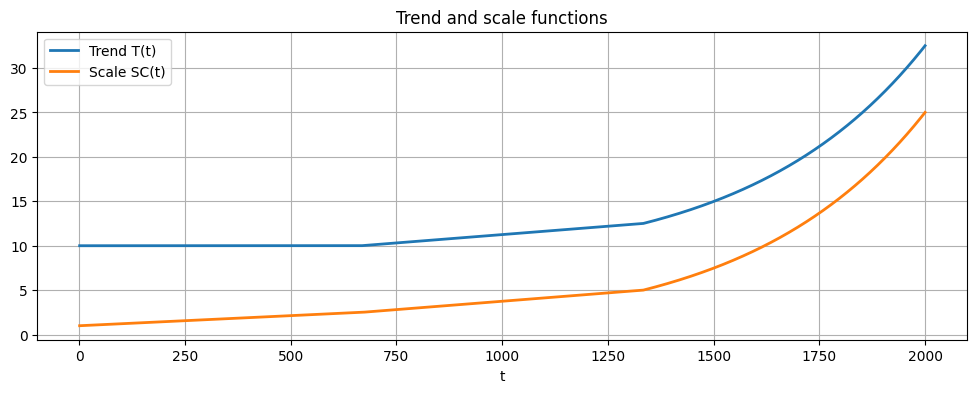

In [135]:
plt.figure(figsize=(12, 4))
plt.plot(t, simulation["T"], label="Trend T(t)", linewidth=2)
plt.plot(t, simulation["SC"], label="Scale SC(t)", linewidth=2)
plt.title("Trend and scale functions")
plt.xlabel("t")
plt.legend()
plt.grid(True)
plt.show()

In [136]:
SC = simulation["SC"]
T = simulation["T"]

idx_tau1 = int(tau1) - 1
idx_tau2 = int(tau2) - 1

boundary_check = pd.DataFrame({
    "quantity": ["SC(1)", "SC(tau1 approx)", "SC(tau2 approx)", "SC(N)", "T(1)", "T(N)"],
    "value": [
        SC[0],
        SC[idx_tau1],
        SC[idx_tau2],
        SC[-1],
        T[0],
        T[-1],
    ]
})

boundary_check

,quantity,value
0,SC(1),1.000000
1,SC(tau1 approx),2.498498
2,SC(tau2 approx),4.998750
3,SC(N),25.000000
4,T(1),10.000000
5,T(N),32.500000


## One-dimensional estimation

The estimation procedure is applied in the reverse order compared to simulation. First, the deterministic trend is estimated using a moving median. Then the trend is removed, the time-varying scale is estimated with a robust scale estimator, and the random component is normalized. Finally, an AR model is fitted to remove temporal dependence, and the stability index $\alpha$ is estimated from the residuals using McCulloch's quantile method.

In [137]:
est = estimate_1d_model(
    simulation["S"],
    trend_window=101,
    scale_window=151,
    p_max=5,
    h_max=30,
    include_zero_order=True,
    relative_tolerance=0.10,
)

summarize_1d_estimation(est)

One-dimensional estimation summary
---------------------------------
Estimated AR order p_opt: 1
Estimated phi: [0.50130107]
Estimated intercept: 0.0
Estimated alpha: 1.9127

AR order candidates:
  p=0: K=0.251303
  p=1: K=0.00372695
  p=2: K=0.00390953
  p=3: K=0.00393131
  p=4: K=0.00357815
  p=5: K=0.00373268


The diagnostic statistic $K$ reached its absolute minimum for $p=4$, but the value obtained for $p=1$ was almost identical. Since the data were generated from an AR(1) process and the robust ACF of the residuals after fitting AR(1) was already close to zero, we selected the simpler AR(1) model. This avoids unnecessary overfitting while preserving the main temporal dependence structure.

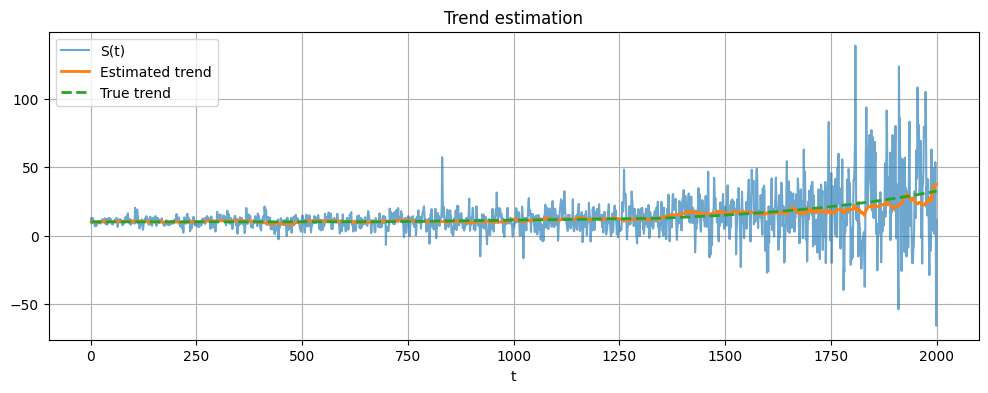

In [138]:
plt.figure(figsize=(12, 4))
plt.plot(t, simulation["S"], label="S(t)", alpha=0.65)
plt.plot(t, est["T_hat"], label="Estimated trend", linewidth=2)
plt.plot(t, simulation["T"], label="True trend", linewidth=2, linestyle="--")
plt.title("Trend estimation")
plt.xlabel("t")
plt.legend()
plt.grid(True)
plt.show()

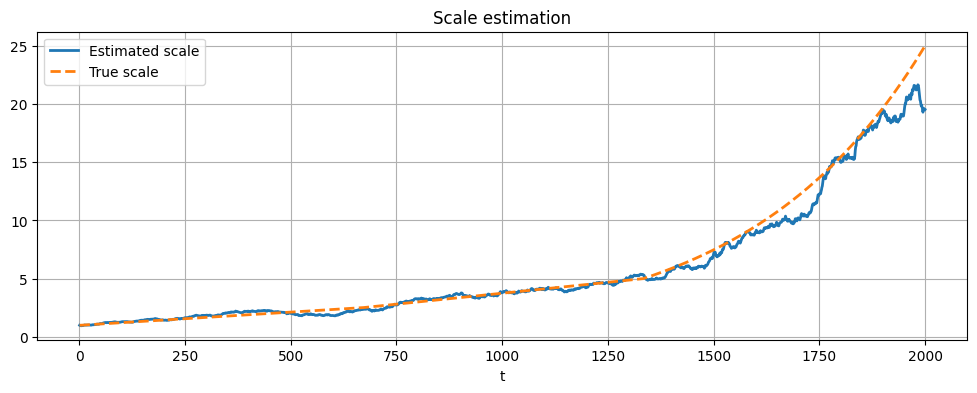

In [140]:
plt.figure(figsize=(12, 4))
plt.plot(t, est["SC_hat"], label="Estimated scale", linewidth=2)
plt.plot(t, simulation["SC"], label="True scale", linewidth=2, linestyle="--")
plt.title("Scale estimation")
plt.xlabel("t")
plt.legend()
plt.grid(True)
plt.show()

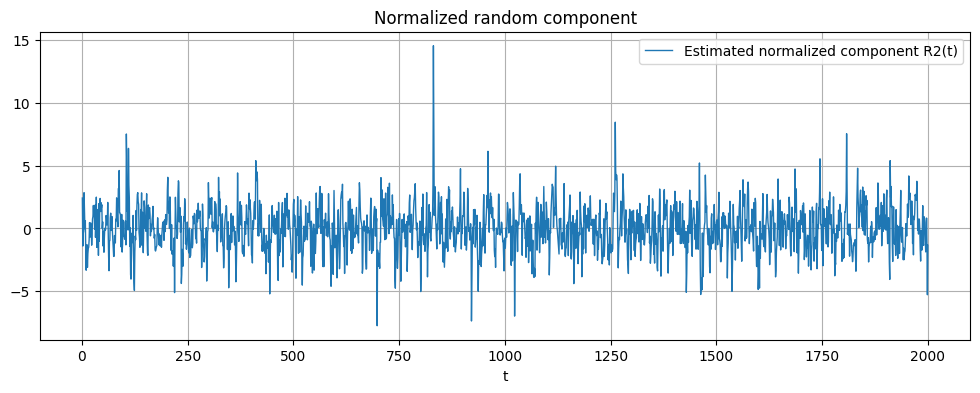

In [141]:
plt.figure(figsize=(12, 4))
plt.plot(t, est["R2_hat"], label="Estimated normalized component R2(t)", linewidth=1)
plt.title("Normalized random component")
plt.xlabel("t")
plt.legend()
plt.grid(True)
plt.show()

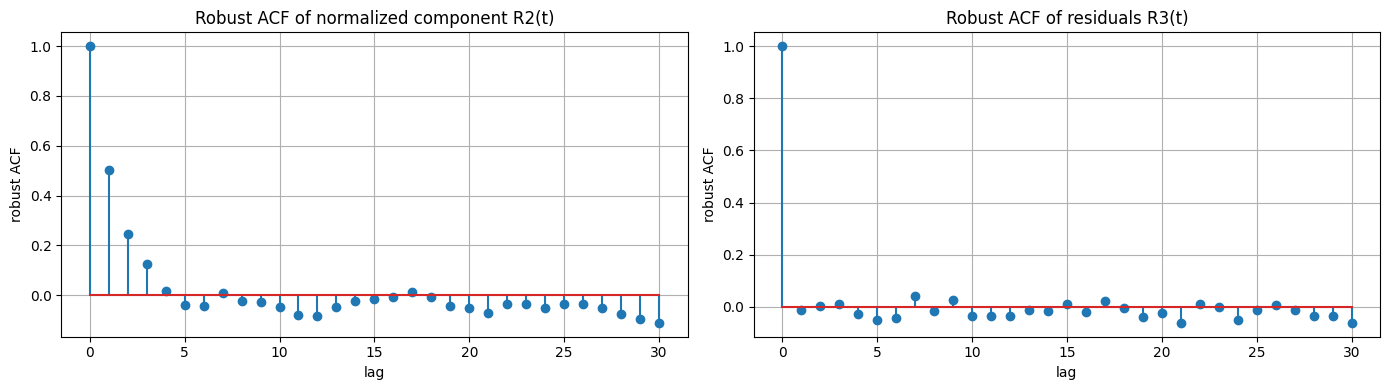

In [142]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].stem(range(len(est["acf_R2"])), est["acf_R2"])
axes[0].set_title("Robust ACF of normalized component R2(t)")
axes[0].set_xlabel("lag")
axes[0].set_ylabel("robust ACF")
axes[0].grid(True)

axes[1].stem(range(len(est["acf_R3"])), est["acf_R3"])
axes[1].set_title("Robust ACF of residuals R3(t)")
axes[1].set_xlabel("lag")
axes[1].set_ylabel("robust ACF")
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [143]:
ar_table = pd.DataFrame([
    {
        "p": item["p"],
        "K": item["K"],
        "selected": item["p"] == est["p_opt"],
    }
    for item in est["ar_candidates"]
])

ar_table

,p,K,selected
0,0,0.251303,False
1,1,0.003727,True
2,2,0.003910,False
3,3,0.003931,False
4,4,0.003578,False
5,5,0.003733,False


The diagnostic statistic $K$ is computed from the robust ACF of residuals. The absolute minimum can sometimes be achieved by a higher-order AR model, but the improvement may be negligible. Therefore, we use a simple parsimony rule: we select the smallest AR order whose diagnostic statistic is within 10% of the best value.

In this experiment, $p=1$ is selected. This is consistent with the data-generating process, because the simulated normalized component was generated from an AR(1) model with coefficient $\phi=0.5$.

In [144]:
single_run_summary = pd.DataFrame({
    "parameter": ["alpha", "phi", "AR order"],
    "true value": [1.9, 0.5, 1],
    "estimated value": [
        est["alpha_hat"],
        est["phi_hat"][0] if len(est["phi_hat"]) > 0 else np.nan,
        est["p_opt"],
    ],
})

single_run_summary

,parameter,true value,estimated value
0,alpha,1.9,1.912686
1,phi,0.5,0.501301
2,AR order,1.0,1.000000


## Comparison for different stability indices

We now repeat the simulation and estimation for several values of the stability index:

$$
\alpha \in \{2.00, 1.95, 1.90, 1.85\}.
$$

The case $\alpha=2$ corresponds to the Gaussian case, while smaller values of $\alpha$ produce heavier tails and more impulsive behaviour.

In [145]:
alphas = [2.0, 1.95, 1.9, 1.85]

simulations_by_alpha = {}
estimations_by_alpha = {}

for alpha in alphas:
    sim_alpha = simulate_1d_model(
        **base_params,
        alpha=alpha,
        random_state=42,
    )

    est_alpha = estimate_1d_model(
        sim_alpha["S"],
        trend_window=101,
        scale_window=151,
        p_max=5,
        h_max=30,
        include_zero_order=True,
        relative_tolerance=0.10,
    )

    simulations_by_alpha[alpha] = sim_alpha
    estimations_by_alpha[alpha] = est_alpha

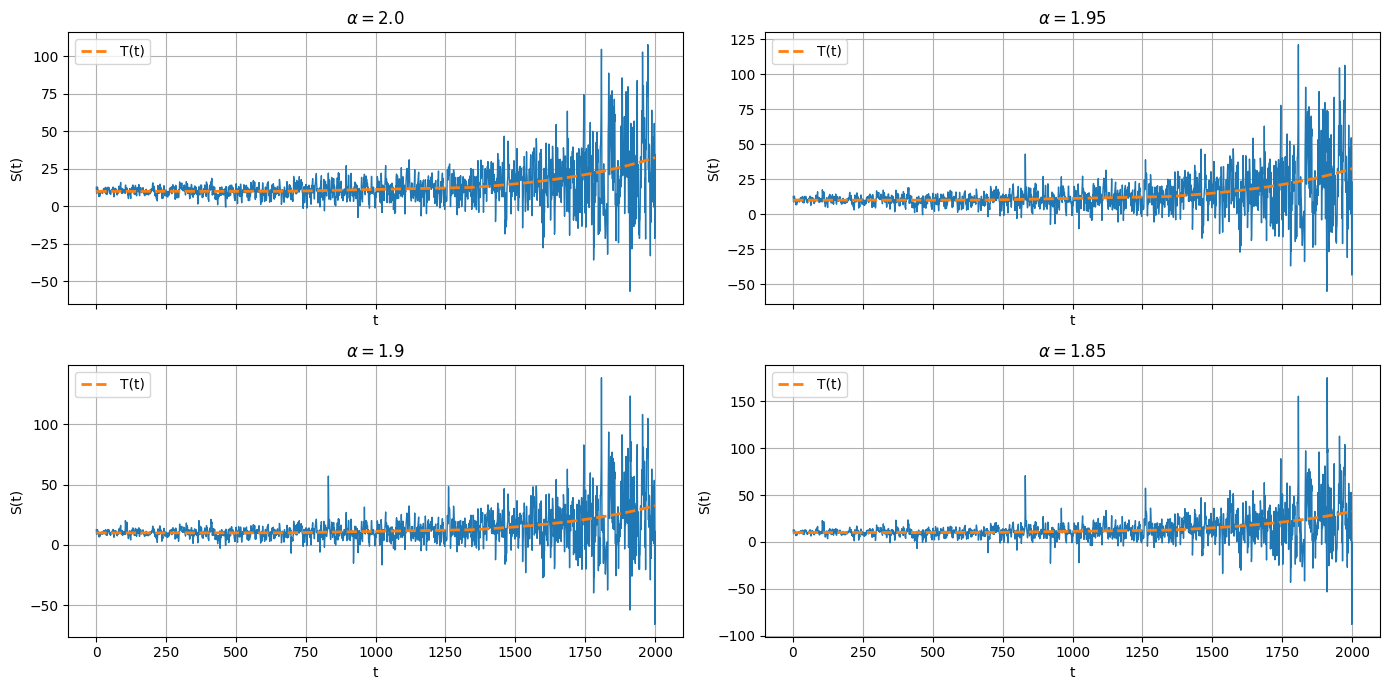

In [148]:
fig, axes = plt.subplots(2, 2, figsize=(14, 7), sharex=True)
axes = axes.ravel()

for ax, alpha in zip(axes, alphas):
    sim_alpha = simulations_by_alpha[alpha]
    ax.plot(sim_alpha["t"], sim_alpha["S"], linewidth=1)
    ax.plot(sim_alpha["t"], sim_alpha["T"], linewidth=2, linestyle="--", label="T(t)")
    ax.set_title(rf"$\alpha = {alpha}$")
    ax.set_xlabel("t")
    ax.set_ylabel("S(t)")
    ax.grid(True)
    ax.legend()

plt.tight_layout()
plt.show()

In [149]:
alpha_comparison_rows = []

for alpha in alphas:
    est_alpha = estimations_by_alpha[alpha]

    phi_est = est_alpha["phi_hat"][0] if len(est_alpha["phi_hat"]) > 0 else np.nan

    alpha_comparison_rows.append({
        "true_alpha": alpha,
        "estimated_alpha": est_alpha["alpha_hat"],
        "true_phi": 0.5,
        "estimated_phi": phi_est,
        "p_opt": est_alpha["p_opt"],
    })

alpha_comparison = pd.DataFrame(alpha_comparison_rows)
alpha_comparison

,true_alpha,estimated_alpha,true_phi,estimated_phi,p_opt
0,2.00,2.000000,0.5,0.492804,1
1,1.95,1.970024,0.5,0.497912,1
2,1.90,1.912686,0.5,0.501301,1
3,1.85,1.845556,0.5,0.503290,1


# MONTE CARLO

To evaluate the estimation procedure more reliably, we repeat the simulation-estimation pipeline several times for each value of $\alpha$. For each replication, a new trajectory is generated and the full estimation procedure is applied.

This allows us to assess the variability of the estimates instead of relying on a single trajectory.

# NEEDED FUNCTIONS

In [106]:
def run_single_1d_experiment(alpha, seed):
    sim_exp = simulate_1d_model(
        **base_params,
        alpha=alpha,
        random_state=seed,
    )

    est_exp = estimate_1d_model(
        sim_exp["S"],
        trend_window=501,
        scale_window=151,
        p_max=5,
        h_max=30,
        include_zero_order=True,
        relative_tolerance=0.10,
    )

    phi_est = est_exp["phi_hat"][0] if len(est_exp["phi_hat"]) > 0 else np.nan

    return {
        "true_alpha": alpha,
        "estimated_alpha": est_exp["alpha_hat"],
        "true_phi": 0.5,
        "estimated_phi": phi_est,
        "p_opt": est_exp["p_opt"],
    }

In [111]:
def run_mc_1d_for_alpha(
    alpha,
    n_replications=100,
    base_seed=10_000,
    trend_window=501,
    scale_window=151,
):
    T_hats = []
    SC_hats = []
    phi_hats = []
    alpha_hats = []

    representative_sim = None
    representative_est = None

    for rep in range(n_replications):
        seed = base_seed + rep

        sim_rep = simulate_1d_model(
            **base_params,
            alpha=alpha,
            random_state=seed,
        )

        est_rep = estimate_1d_model_fixed_ar_order(
            sim_rep["S"],
            trend_window=trend_window,
            scale_window=scale_window,
            ar_order=1,
            h_max=30,
            compute_diagnostics=(rep == 0),
        )

        T_hats.append(est_rep["T_hat"])
        SC_hats.append(est_rep["SC_hat"])
        phi_hats.append(est_rep["phi_hat"][0])
        alpha_hats.append(est_rep["alpha_hat"])

        if rep == 0:
            representative_sim = sim_rep
            representative_est = est_rep

    return {
        "alpha": alpha,
        "t": representative_sim["t"],
        "true_T": representative_sim["T"],
        "true_SC": representative_sim["SC"],
        "T_hats": np.asarray(T_hats),
        "SC_hats": np.asarray(SC_hats),
        "phi_hats": np.asarray(phi_hats),
        "alpha_hats": np.asarray(alpha_hats),
        "representative_sim": representative_sim,
        "representative_est": representative_est,
    }

In [114]:
def plot_mc_1d_estimation_results(result, true_phi=0.5):
    """
    Plots Monte Carlo estimation results for one value of alpha.

    Layout:
    - estimated trend trajectories and true trend,
    - estimated scale trajectories and true scale,
    - boxplot of phi estimates,
    - boxplot of alpha estimates.
    """
    alpha = result["alpha"]
    t = result["t"]

    T_hats = result["T_hats"]
    SC_hats = result["SC_hats"]
    phi_hats = result["phi_hats"]
    alpha_hats = result["alpha_hats"]

    true_T = result["true_T"]
    true_SC = result["true_SC"]

    fig, axes = plt.subplots(2, 2, figsize=(13, 8))

    # Estimated trend trajectories
    ax = axes[0, 0]
    for T_hat_i in T_hats:
        ax.plot(t, T_hat_i, color="gray", alpha=0.18, linewidth=0.8)
    ax.plot(t, true_T, color="blue", linewidth=2.5, label="True trend")
    ax.set_title(rf"Estimated trend trajectories, $\alpha={alpha}$")
    ax.set_xlabel("t")
    ax.set_ylabel("T(t)")
    ax.grid(True, alpha=0.4)
    ax.legend()

    # Estimated scale trajectories
    ax = axes[0, 1]
    for SC_hat_i in SC_hats:
        ax.plot(t, SC_hat_i, color="gray", alpha=0.18, linewidth=0.8)
    ax.plot(t, true_SC, color="orange", linewidth=2.5, label="True scale")
    ax.set_title(rf"Estimated scale trajectories, $\alpha={alpha}$")
    ax.set_xlabel("t")
    ax.set_ylabel("SC(t)")
    ax.grid(True, alpha=0.4)
    ax.legend()

    # Boxplot phi
    ax = axes[1, 0]
    ax.boxplot(phi_hats, labels=[r"$\hat{\phi}$"])
    ax.axhline(true_phi, linestyle="--", color="red", label=rf"true $\phi={true_phi}$")
    ax.set_title("Distribution of AR(1) coefficient estimates")
    ax.set_ylabel(r"$\hat{\phi}$")
    ax.grid(True, alpha=0.4)
    ax.legend()

    # Boxplot alpha
    ax = axes[1, 1]
    ax.boxplot(alpha_hats, labels=[r"$\hat{\alpha}$"])
    ax.axhline(alpha, linestyle="--", color="red", label=rf"true $\alpha={alpha}$")
    ax.set_title("Distribution of stability index estimates")
    ax.set_ylabel(r"$\hat{\alpha}$")
    ax.grid(True, alpha=0.4)
    ax.legend()

    fig.suptitle(
        rf"Monte Carlo estimation results for the one-dimensional model, $\alpha={alpha}$",
        fontsize=14
    )
    plt.tight_layout()
    plt.show()

In [115]:
def plot_representative_acf_1d(result, ci_level=0.95):
    """
    Plots robust ACF before and after AR(1) fitting
    for one representative Monte Carlo replication,
    with approximate confidence bands.
    """
    alpha = result["alpha"]
    est_rep = result["representative_est"]

    acf_R2 = est_rep["acf_R2"]
    acf_R3 = est_rep["acf_R3"]

    R2_hat = est_rep["R2_hat"]
    R3_hat = est_rep["R3_hat"]

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    if ci_level == 0.95:
        z_value = 1.96
    elif ci_level == 0.90:
        z_value = 1.645
    else:
        raise ValueError("Use ci_level=0.95 or ci_level=0.90.")

    band_R2 = z_value / np.sqrt(len(R2_hat))
    band_R3 = z_value / np.sqrt(len(R3_hat))

    lags_R2 = np.arange(len(acf_R2))
    lags_R3 = np.arange(len(acf_R3))

    axes[0].stem(lags_R2, acf_R2)
    axes[0].axhline(0, linewidth=1)
    axes[0].axhline(band_R2, linestyle="--", label=f"{int(ci_level*100)}% band")
    axes[0].axhline(-band_R2, linestyle="--")
    axes[0].set_title(rf"Before AR(1): robust ACF of $R2(t)$, $\alpha={alpha}$")
    axes[0].set_xlabel("Lag")
    axes[0].set_ylabel("Robust ACF")
    axes[0].grid(True)
    axes[0].legend()

    axes[1].stem(lags_R3, acf_R3)
    axes[1].axhline(0, linewidth=1)
    axes[1].axhline(band_R3, linestyle="--", label=f"{int(ci_level*100)}% band")
    axes[1].axhline(-band_R3, linestyle="--")
    axes[1].set_title(rf"After AR(1): robust ACF of residuals, $\alpha={alpha}$")
    axes[1].set_xlabel("Lag")
    axes[1].set_ylabel("Robust ACF")
    axes[1].grid(True)
    axes[1].legend()

    plt.tight_layout()
    plt.show()

## Optional mean bias plot and band

In [117]:
def plot_mc_1d_mean_bias(result):
    alpha = result["alpha"]
    t = result["t"]

    mean_T_hat = np.mean(result["T_hats"], axis=0)
    mean_SC_hat = np.mean(result["SC_hats"], axis=0)

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    axes[0].plot(t, result["true_T"], linewidth=2.5, linestyle="--", label="True trend")
    axes[0].plot(t, mean_T_hat, linewidth=2, label="Mean estimated trend")
    axes[0].set_title(rf"Mean trend estimate, $\alpha={alpha}$")
    axes[0].set_xlabel("t")
    axes[0].set_ylabel("T(t)")
    axes[0].grid(True, alpha=0.4)
    axes[0].legend()

    axes[1].plot(t, result["true_SC"], linewidth=2.5, linestyle="--", label="True scale")
    axes[1].plot(t, mean_SC_hat, linewidth=2, label="Mean estimated scale")
    axes[1].set_title(rf"Mean scale estimate, $\alpha={alpha}$")
    axes[1].set_xlabel("t")
    axes[1].set_ylabel("SC(t)")
    axes[1].grid(True, alpha=0.4)
    axes[1].legend()

    plt.tight_layout()
    plt.show()

In [119]:
def plot_mc_1d_median_band(result):
    alpha = result["alpha"]
    t = result["t"]

    T_hats = result["T_hats"]
    SC_hats = result["SC_hats"]

    median_T_hat = np.median(T_hats, axis=0)
    q05_T = np.quantile(T_hats, 0.05, axis=0)
    q95_T = np.quantile(T_hats, 0.95, axis=0)

    median_SC_hat = np.median(SC_hats, axis=0)
    q05_SC = np.quantile(SC_hats, 0.05, axis=0)
    q95_SC = np.quantile(SC_hats, 0.95, axis=0)

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    axes[0].fill_between(t, q05_T, q95_T, alpha=0.25, label="5%-95% band")
    axes[0].plot(t, result["true_T"], linewidth=2.5, linestyle="--", label="True trend")
    axes[0].plot(t, median_T_hat, linewidth=2, label="Median estimated trend")
    axes[0].set_title(rf"Median trend estimate, $\alpha={alpha}$")
    axes[0].set_xlabel("t")
    axes[0].set_ylabel("T(t)")
    axes[0].grid(True)
    axes[0].legend()

    axes[1].fill_between(t, q05_SC, q95_SC, alpha=0.25, label="5%-95% band")
    axes[1].plot(t, result["true_SC"], linewidth=2.5, linestyle="--", label="True scale")
    axes[1].plot(t, median_SC_hat, linewidth=2, label="Median estimated scale")
    axes[1].set_title(rf"Median scale estimate, $\alpha={alpha}$")
    axes[1].set_xlabel("t")
    axes[1].set_ylabel("SC(t)")
    axes[1].grid(True)
    axes[1].legend()

    plt.tight_layout()
    plt.show()

# SiMULATION (FOR N=100)

In [124]:
mc_1d_final = {}

alphas_order = [1.85, 1.90, 1.95, 2.00]
n_replications = 100

for idx, alpha in enumerate(alphas_order):
    print(f"Running FINAL Monte Carlo for alpha={alpha}...")
    mc_1d_final[alpha] = run_mc_1d_for_alpha(
        alpha=alpha,
        n_replications=n_replications,
        base_seed=10_000 + idx * 10_000,
        trend_window=501,
        scale_window=151,
    )

print("Done.")

Running FINAL Monte Carlo for alpha=1.85...
Running FINAL Monte Carlo for alpha=1.9...
Running FINAL Monte Carlo for alpha=1.95...
Running FINAL Monte Carlo for alpha=2.0...
Done.


In [125]:
final_summary = []

for alpha in alphas_order:
    final_summary.append({
        "alpha": alpha,
        "mean_phi": np.mean(mc_1d_final[alpha]["phi_hats"]),
        "median_phi": np.median(mc_1d_final[alpha]["phi_hats"]),
        "std_phi": np.std(mc_1d_final[alpha]["phi_hats"], ddof=1),
        "mean_alpha_hat": np.mean(mc_1d_final[alpha]["alpha_hats"]),
        "median_alpha_hat": np.median(mc_1d_final[alpha]["alpha_hats"]),
    })

final_summary = pd.DataFrame(final_summary)
final_summary

,alpha,mean_phi,median_phi,std_phi,mean_alpha_hat,median_alpha_hat
0,1.85,0.506525,0.507124,0.020441,1.867957,1.866071
1,1.90,0.500638,0.502745,0.021544,1.908314,1.913825
2,1.95,0.496793,0.495754,0.020993,1.939421,1.954353
3,2.00,0.491720,0.494268,0.022605,1.971059,2.000000


In [129]:
mc_summary_rows = []

for alpha in alphas_order:
    result = mc_1d_final[alpha]

    mc_summary_rows.append({
        "true_alpha": alpha,
        "mean_alpha_hat": np.mean(result["alpha_hats"]),
        "std_alpha_hat": np.std(result["alpha_hats"], ddof=1),
        "median_alpha_hat": np.median(result["alpha_hats"]),
        "mean_phi_hat": np.mean(result["phi_hats"]),
        "std_phi_hat": np.std(result["phi_hats"], ddof=1),
        "median_phi_hat": np.median(result["phi_hats"]),
        "true_phi": 0.5,
        "n_replications": n_replications,
    })

mc_summary_1d = pd.DataFrame(mc_summary_rows)
mc_summary_1d

,true_alpha,mean_alpha_hat,std_alpha_hat,median_alpha_hat,mean_phi_hat,std_phi_hat,median_phi_hat,true_phi,n_replications
0,1.85,1.867957,0.072825,1.866071,0.506525,0.020441,0.507124,0.5,100
1,1.90,1.908314,0.064777,1.913825,0.500638,0.021544,0.502745,0.5,100
2,1.95,1.939421,0.057825,1.954353,0.496793,0.020993,0.495754,0.5,100
3,2.00,1.971059,0.046542,2.000000,0.491720,0.022605,0.494268,0.5,100


/var/folders/ht/v4yd2jps515c6dfg2cm1zydc0000gn/T/ipykernel_18599/4056710741.py:48: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(phi_hats, labels=[r"$\hat{\phi}$"])
/var/folders/ht/v4yd2jps515c6dfg2cm1zydc0000gn/T/ipykernel_18599/4056710741.py:57: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(alpha_hats, labels=[r"$\hat{\alpha}$"])


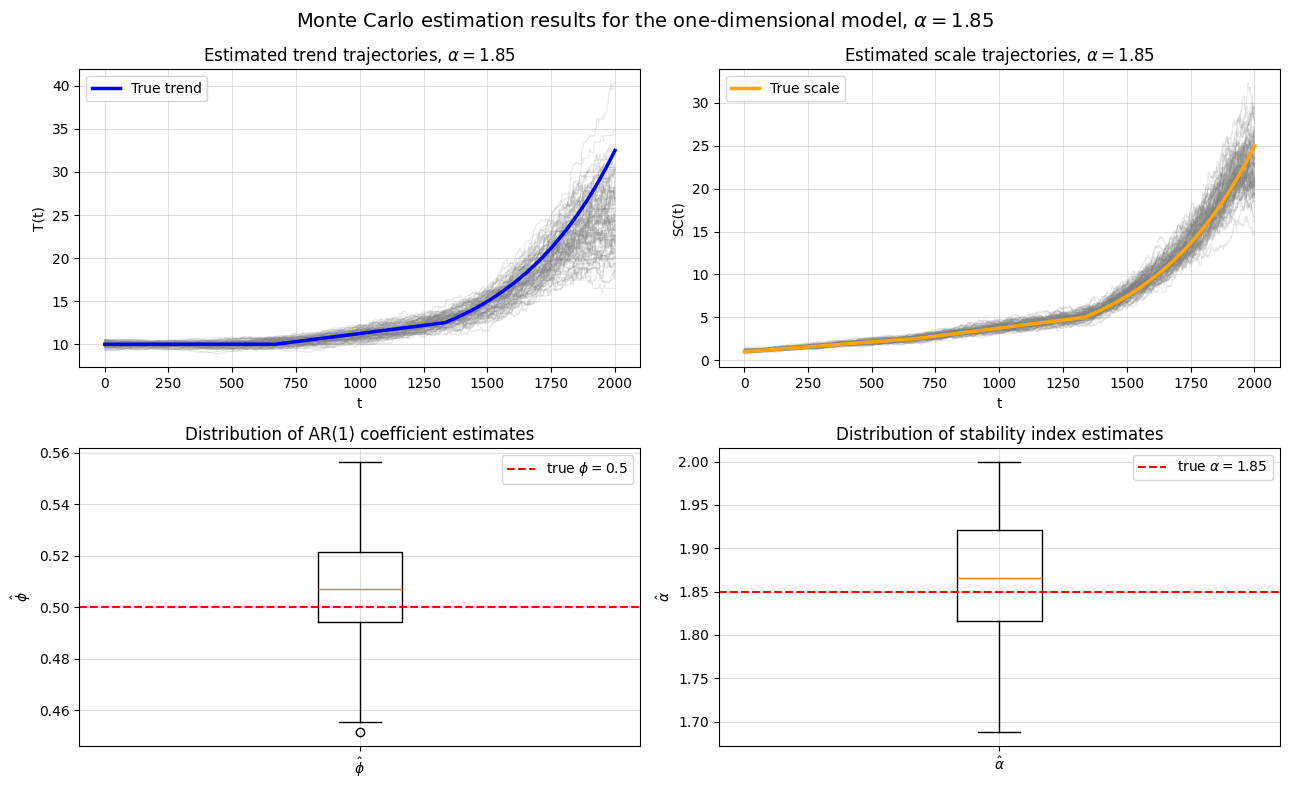

/var/folders/ht/v4yd2jps515c6dfg2cm1zydc0000gn/T/ipykernel_18599/4056710741.py:48: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(phi_hats, labels=[r"$\hat{\phi}$"])
/var/folders/ht/v4yd2jps515c6dfg2cm1zydc0000gn/T/ipykernel_18599/4056710741.py:57: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(alpha_hats, labels=[r"$\hat{\alpha}$"])


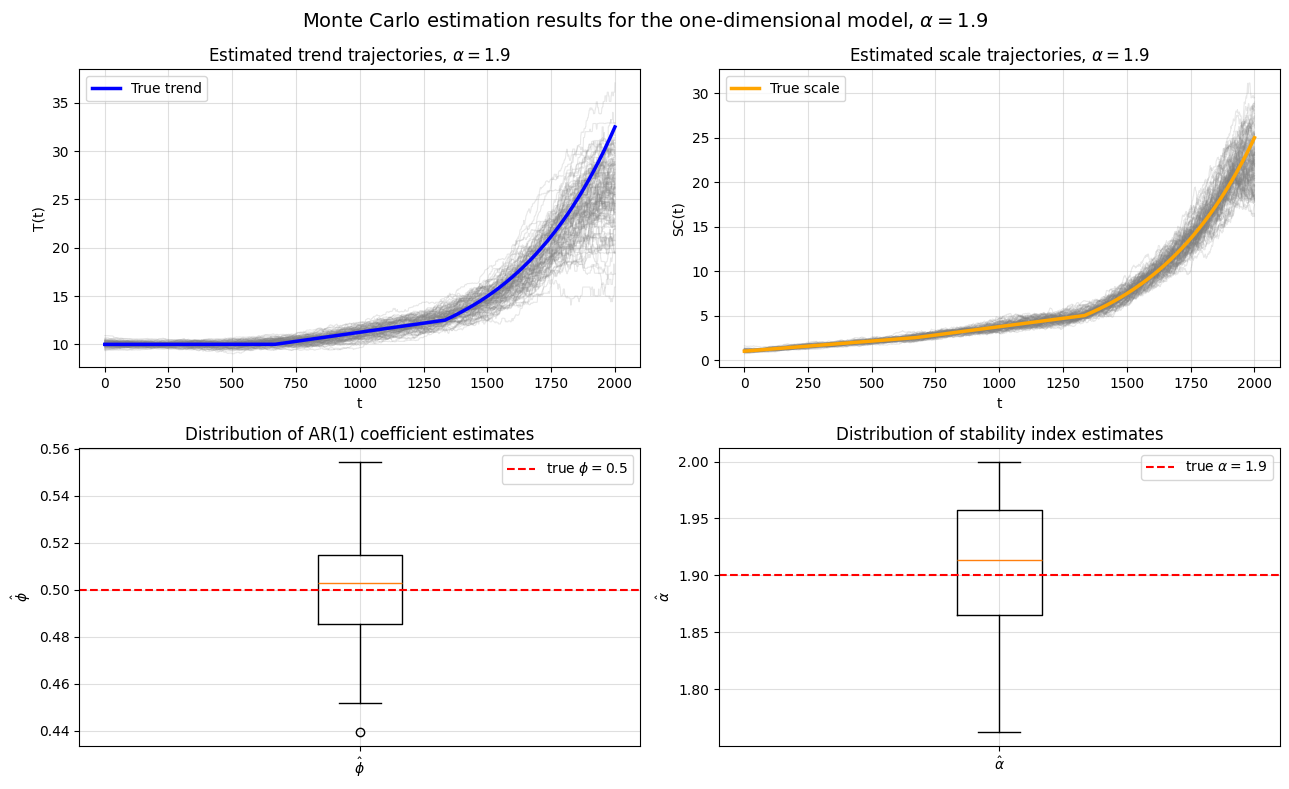

/var/folders/ht/v4yd2jps515c6dfg2cm1zydc0000gn/T/ipykernel_18599/4056710741.py:48: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(phi_hats, labels=[r"$\hat{\phi}$"])
/var/folders/ht/v4yd2jps515c6dfg2cm1zydc0000gn/T/ipykernel_18599/4056710741.py:57: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(alpha_hats, labels=[r"$\hat{\alpha}$"])


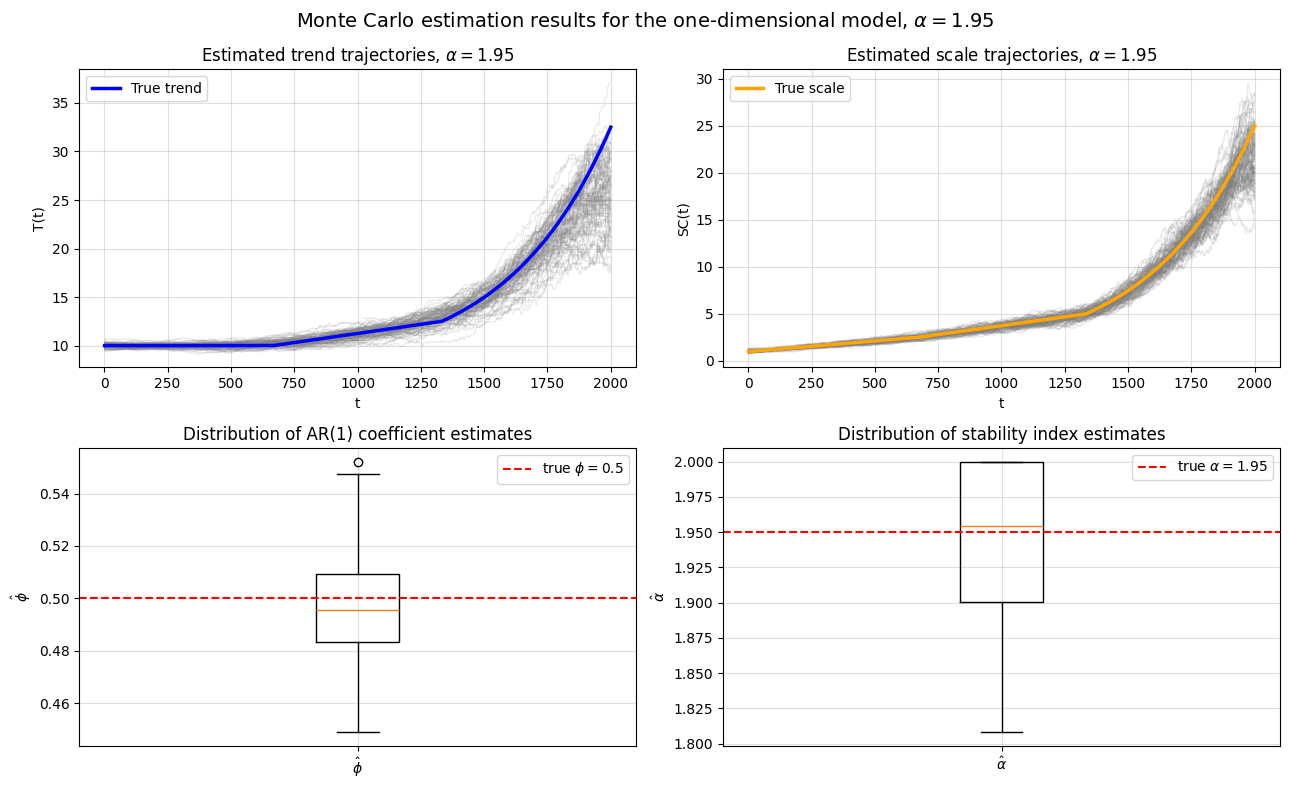

/var/folders/ht/v4yd2jps515c6dfg2cm1zydc0000gn/T/ipykernel_18599/4056710741.py:48: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(phi_hats, labels=[r"$\hat{\phi}$"])
/var/folders/ht/v4yd2jps515c6dfg2cm1zydc0000gn/T/ipykernel_18599/4056710741.py:57: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(alpha_hats, labels=[r"$\hat{\alpha}$"])


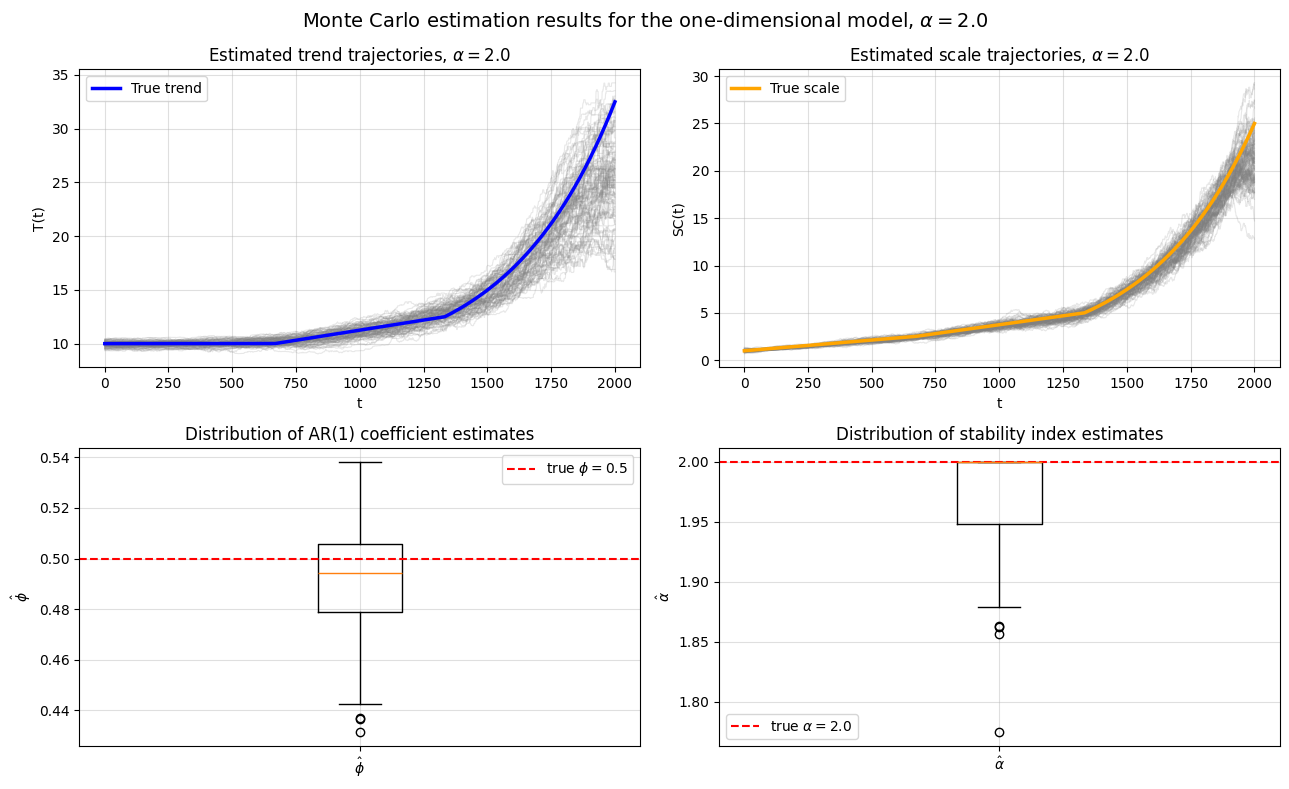

In [126]:
for alpha in alphas_order:
    plot_mc_1d_estimation_results(mc_1d_final[alpha], true_phi=0.5)

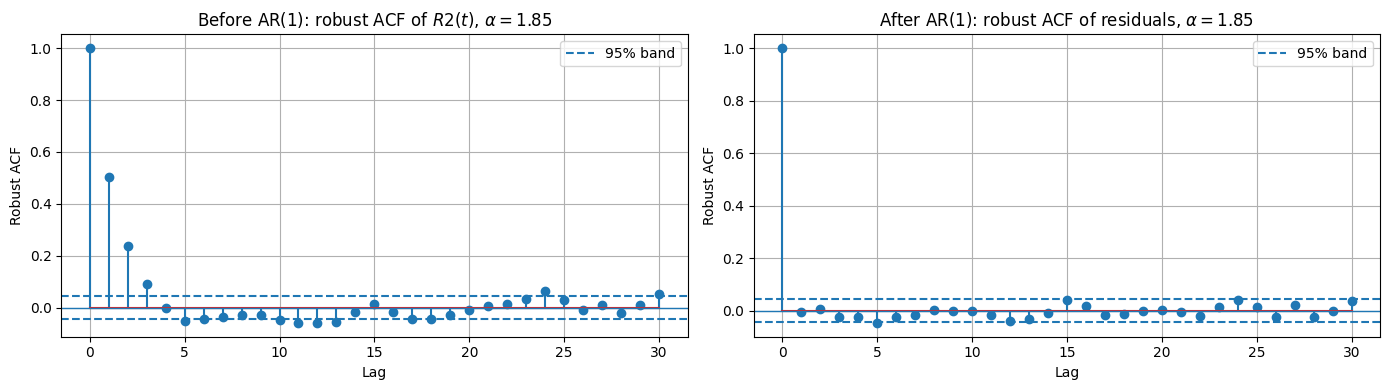

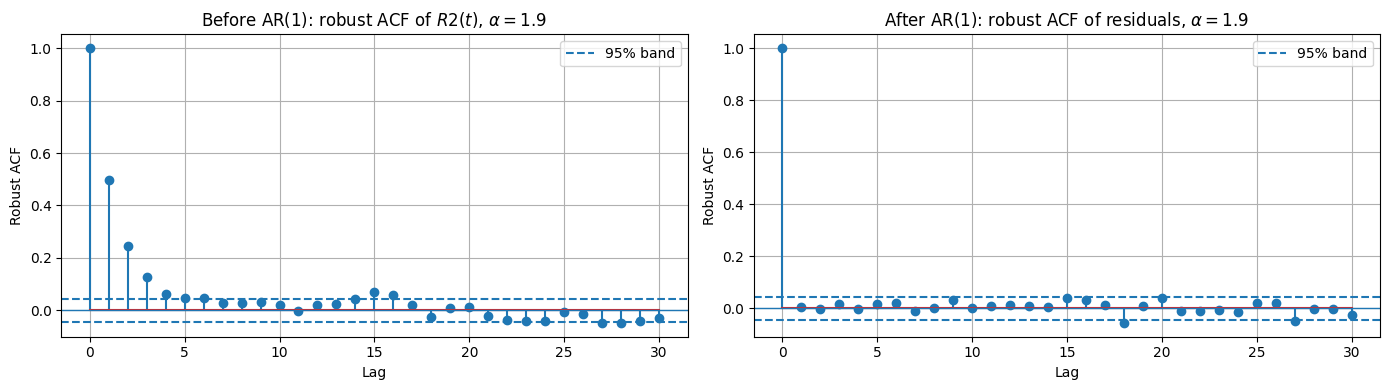

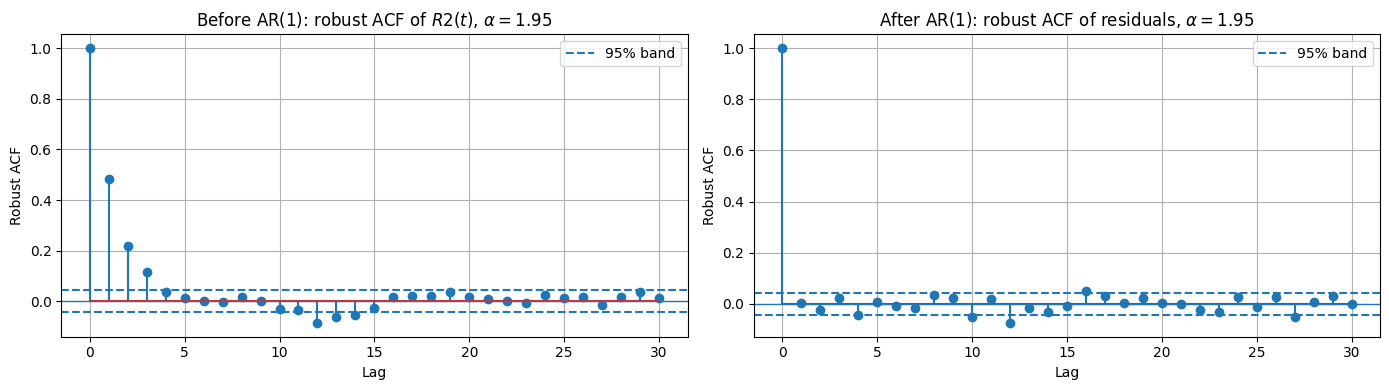

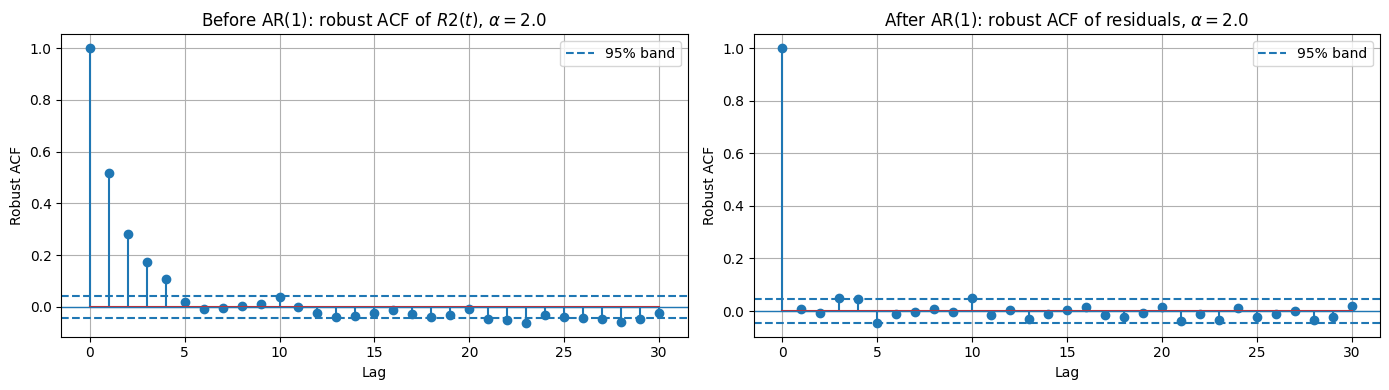

In [130]:
for alpha in alphas_order:
    plot_representative_acf_1d(mc_1d_final[alpha], ci_level=0.95)

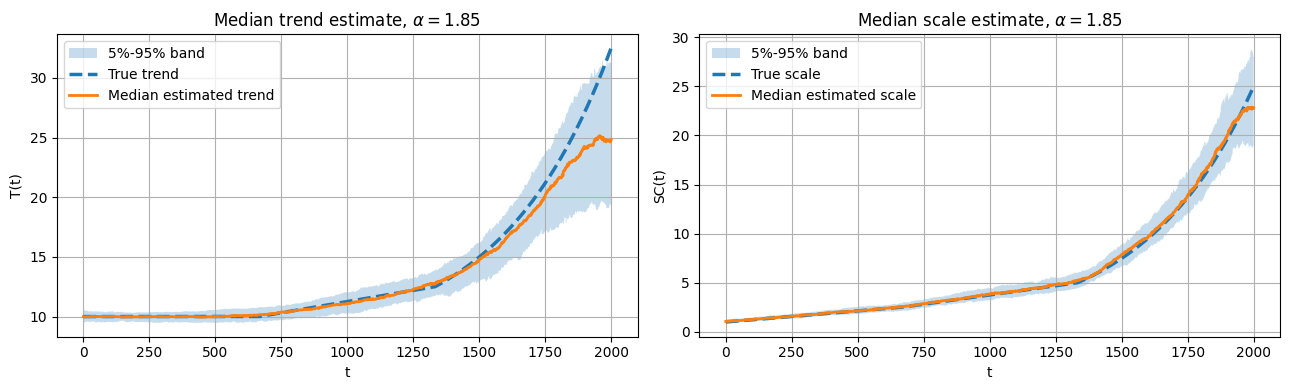

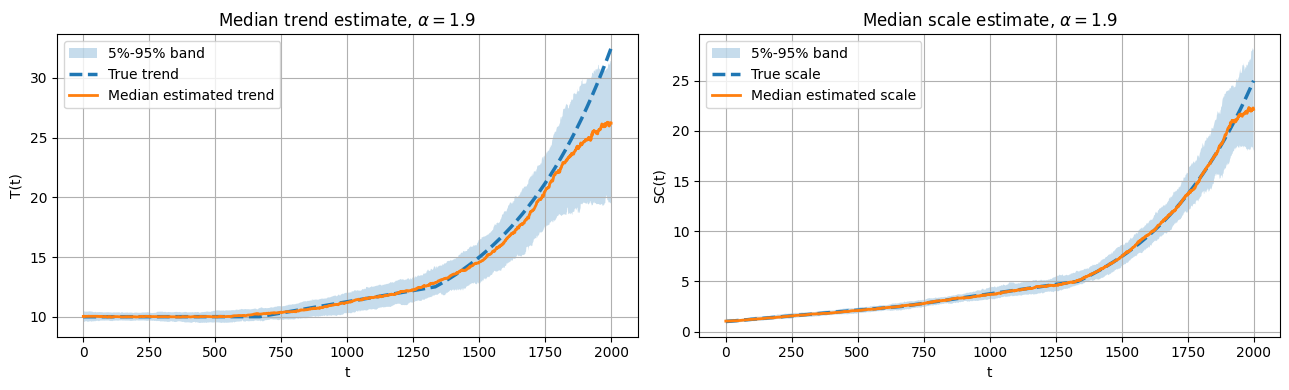

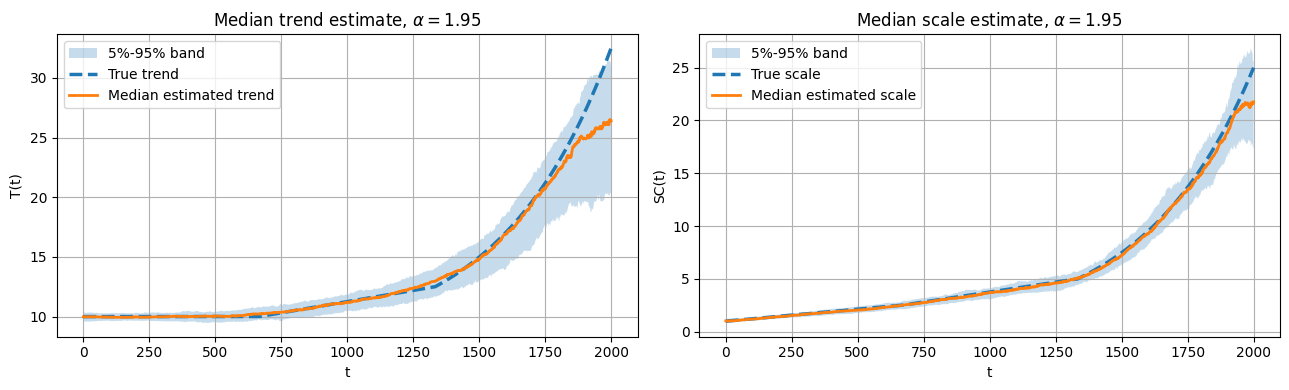

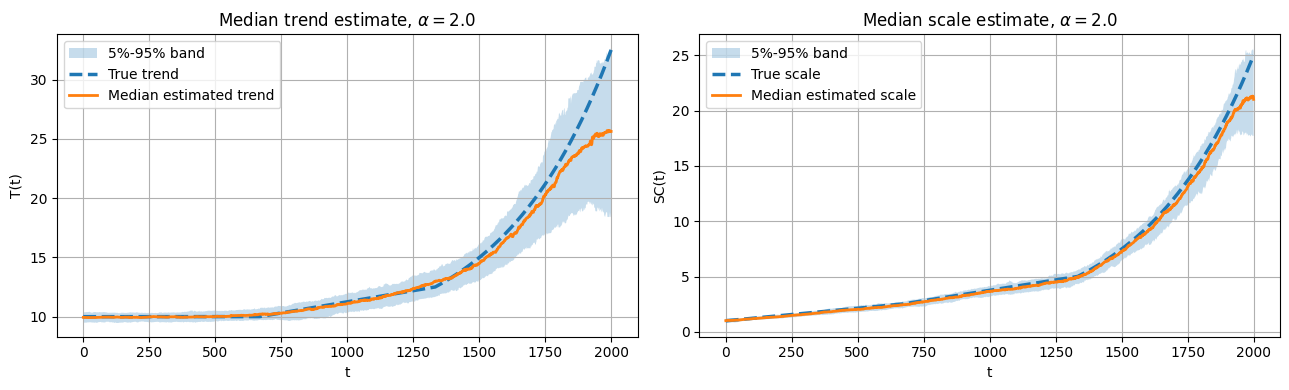

In [127]:
for alpha in alphas_order:
    plot_mc_1d_median_band(mc_1d_final[alpha])

# UWAGA - dodatek

# uwaga uwaga uwaga uwaga

TESTY KTORE UDOWADNIAJA WINE TREND_WINDOW NA BOXPLOTY (NAJPIERW TESTY SCALE_WINDOW POTEM TREND)

In [72]:
def run_phi_window_test(
    alpha=2.0,
    scale_windows=(51, 101, 151, 201, 251, 301),
    trend_window=101,
    n_replications=30,
):
    rows = []

    for scale_window in scale_windows:
        phi_hats = []
        alpha_hats = []

        for rep in range(n_replications):
            sim_rep = simulate_1d_model(
                **base_params,
                alpha=alpha,
                random_state=120_000 + int(alpha * 1000) + 1000 * scale_window + rep,
            )

            est_rep = estimate_1d_model_fixed_ar_order(
                sim_rep["S"],
                trend_window=trend_window,
                scale_window=scale_window,
                ar_order=1,
                h_max=30,
                compute_diagnostics=False,
            )

            phi_hats.append(est_rep["phi_hat"][0])
            alpha_hats.append(est_rep["alpha_hat"])

        rows.append({
            "alpha": alpha,
            "trend_window": trend_window,
            "scale_window": scale_window,
            "mean_phi_hat": np.mean(phi_hats),
            "median_phi_hat": np.median(phi_hats),
            "std_phi_hat": np.std(phi_hats, ddof=1),
            "mean_alpha_hat": np.mean(alpha_hats),
            "median_alpha_hat": np.median(alpha_hats),
        })

    return pd.DataFrame(rows)

In [73]:
phi_window_test_alpha2 = run_phi_window_test(
    alpha=2.0,
    scale_windows=(51, 101, 151, 201, 251, 301),
    trend_window=101,
    n_replications=30,
)

phi_window_test_alpha2

,alpha,trend_window,scale_window,mean_phi_hat,median_phi_hat,std_phi_hat,mean_alpha_hat,median_alpha_hat
0,2.0,101,51,0.476494,0.475669,0.017945,1.975861,2.000000
1,2.0,101,101,0.483028,0.485901,0.020690,1.942749,1.944591
2,2.0,101,151,0.481079,0.480691,0.022314,1.978426,2.000000
3,2.0,101,201,0.479807,0.481220,0.022569,1.978877,2.000000
4,2.0,101,251,0.476892,0.477945,0.022245,1.961929,1.997753
5,2.0,101,301,0.474152,0.472713,0.025256,1.961077,1.995154


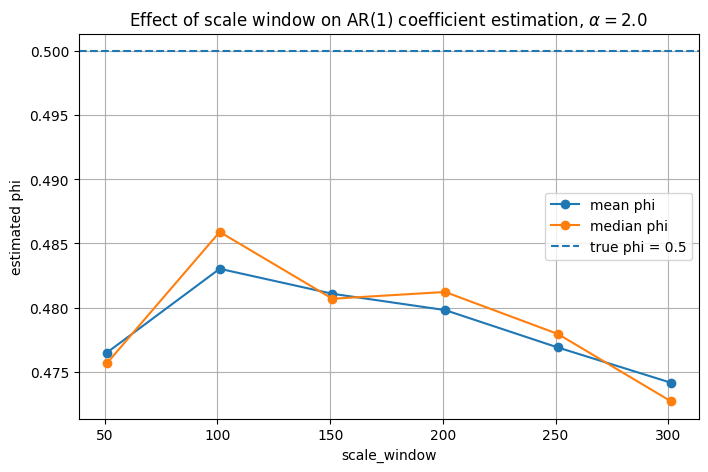

In [74]:
plt.figure(figsize=(8, 5))
plt.plot(phi_window_test_alpha2["scale_window"], phi_window_test_alpha2["mean_phi_hat"], marker="o", label="mean phi")
plt.plot(phi_window_test_alpha2["scale_window"], phi_window_test_alpha2["median_phi_hat"], marker="o", label="median phi")
plt.axhline(0.5, linestyle="--", label="true phi = 0.5")
plt.xlabel("scale_window")
plt.ylabel("estimated phi")
plt.title(r"Effect of scale window on AR(1) coefficient estimation, $\alpha=2.0$")
plt.grid(True)
plt.legend()
plt.show()

In [75]:
phi_window_test_alpha19 = run_phi_window_test(
    alpha=1.9,
    scale_windows=(51, 101, 151, 201, 251, 301),
    trend_window=101,
    n_replications=30,
)

phi_window_test_alpha19

,alpha,trend_window,scale_window,mean_phi_hat,median_phi_hat,std_phi_hat,mean_alpha_hat,median_alpha_hat
0,1.9,101,51,0.484673,0.485954,0.026067,1.887961,1.886544
1,1.9,101,101,0.491553,0.487513,0.020793,1.894771,1.876971
2,1.9,101,151,0.489849,0.486430,0.023520,1.913957,1.916210
3,1.9,101,201,0.485253,0.486333,0.024630,1.895267,1.915579
4,1.9,101,251,0.489405,0.486145,0.024653,1.888176,1.901771
5,1.9,101,301,0.487088,0.491884,0.024879,1.865309,1.845367


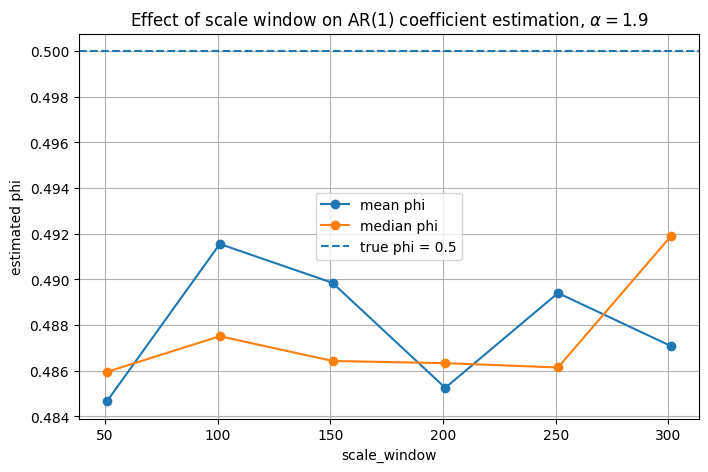

In [76]:
plt.figure(figsize=(8, 5))
plt.plot(phi_window_test_alpha19["scale_window"], phi_window_test_alpha19["mean_phi_hat"], marker="o", label="mean phi")
plt.plot(phi_window_test_alpha19["scale_window"], phi_window_test_alpha19["median_phi_hat"], marker="o", label="median phi")
plt.axhline(0.5, linestyle="--", label="true phi = 0.5")
plt.xlabel("scale_window")
plt.ylabel("estimated phi")
plt.title(r"Effect of scale window on AR(1) coefficient estimation, $\alpha=1.9$")
plt.grid(True)
plt.legend()
plt.show()

In [77]:
from estimation1d import (
    remove_trend,
    rolling_scq_scale,
    normalize_random_component,
    estimate_ar_yule_walker_robust,
)

def estimate_phi_from_series_R2(R2):
    phi_hat, intercept_hat, info = estimate_ar_yule_walker_robust(R2, p=1)
    return phi_hat[0]


def run_phi_source_diagnostic(
    alpha=2.0,
    trend_window=101,
    scale_window=151,
    n_replications=50,
):
    rows = []

    for rep in range(n_replications):
        sim_rep = simulate_1d_model(
            **base_params,
            alpha=alpha,
            random_state=150_000 + int(alpha * 1000) + rep,
        )

        S = sim_rep["S"]
        T_true = sim_rep["T"]
        SC_true = sim_rep["SC"]
        R_true = sim_rep["R"]
        R2_true = sim_rep["R2"]

        # 1. Oracle: true R2
        phi_oracle_R2 = estimate_phi_from_series_R2(R2_true)

        # 2. True trend + true scale
        R_from_true_T = S - T_true
        R2_true_T_true_SC = R_from_true_T / SC_true
        phi_true_T_true_SC = estimate_phi_from_series_R2(R2_true_T_true_SC)

        # 3. Estimated trend + true scale
        R_hat, T_hat = remove_trend(S, trend_window=trend_window)
        R2_est_T_true_SC = R_hat / SC_true
        phi_est_T_true_SC = estimate_phi_from_series_R2(R2_est_T_true_SC)

        # 4. True trend + estimated scale
        SC_hat_from_true_R = rolling_scq_scale(R_true, window=scale_window)
        R2_true_T_est_SC = R_true / SC_hat_from_true_R
        phi_true_T_est_SC = estimate_phi_from_series_R2(R2_true_T_est_SC)

        # 5. Full pipeline
        SC_hat_from_R_hat = rolling_scq_scale(R_hat, window=scale_window)
        R2_full = R_hat / SC_hat_from_R_hat
        phi_full = estimate_phi_from_series_R2(R2_full)

        rows.extend([
            {
                "alpha": alpha,
                "replication": rep,
                "variant": "oracle_true_R2",
                "phi_hat": phi_oracle_R2,
            },
            {
                "alpha": alpha,
                "replication": rep,
                "variant": "true_trend_true_scale",
                "phi_hat": phi_true_T_true_SC,
            },
            {
                "alpha": alpha,
                "replication": rep,
                "variant": "estimated_trend_true_scale",
                "phi_hat": phi_est_T_true_SC,
            },
            {
                "alpha": alpha,
                "replication": rep,
                "variant": "true_trend_estimated_scale",
                "phi_hat": phi_true_T_est_SC,
            },
            {
                "alpha": alpha,
                "replication": rep,
                "variant": "full_pipeline",
                "phi_hat": phi_full,
            },
        ])

    return pd.DataFrame(rows)

In [78]:
phi_source_alpha2 = run_phi_source_diagnostic(
    alpha=2.0,
    trend_window=101,
    scale_window=151,
    n_replications=50,
)

phi_source_summary_alpha2 = (
    phi_source_alpha2
    .groupby("variant")
    .agg(
        mean_phi_hat=("phi_hat", "mean"),
        median_phi_hat=("phi_hat", "median"),
        std_phi_hat=("phi_hat", "std"),
    )
    .reset_index()
)

phi_source_summary_alpha2

,variant,mean_phi_hat,median_phi_hat,std_phi_hat
0,estimated_trend_true_scale,0.485743,0.485840,0.019577
1,full_pipeline,0.482897,0.482109,0.019344
2,oracle_true_R2,0.501829,0.503141,0.019641
3,true_trend_estimated_scale,0.499251,0.500974,0.019394
4,true_trend_true_scale,0.501829,0.503141,0.019641


<Figure size 1100x500 with 0 Axes>

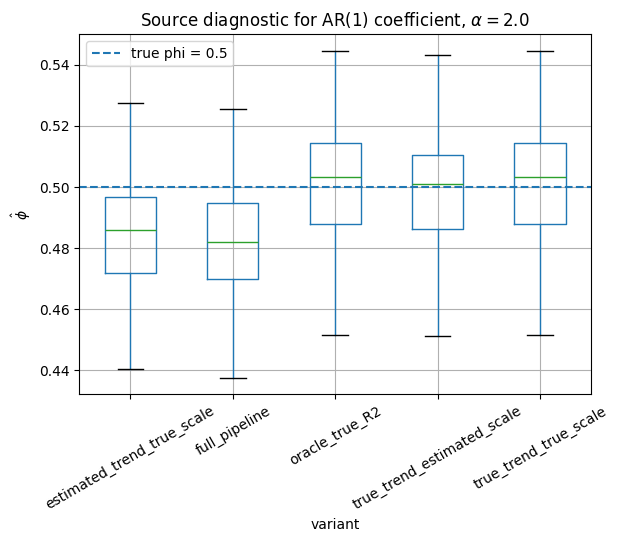

In [79]:
plt.figure(figsize=(11, 5))
phi_source_alpha2.boxplot(column="phi_hat", by="variant", rot=30)
plt.axhline(0.5, linestyle="--", label="true phi = 0.5")
plt.title(r"Source diagnostic for AR(1) coefficient, $\alpha=2.0$")
plt.suptitle("")
plt.ylabel(r"$\hat{\phi}$")
plt.grid(True)
plt.legend()
plt.show()

In [80]:
phi_source_alpha19 = run_phi_source_diagnostic(
    alpha=1.9,
    trend_window=101,
    scale_window=151,
    n_replications=50,
)

phi_source_summary_alpha19 = (
    phi_source_alpha19
    .groupby("variant")
    .agg(
        mean_phi_hat=("phi_hat", "mean"),
        median_phi_hat=("phi_hat", "median"),
        std_phi_hat=("phi_hat", "std"),
    )
    .reset_index()
)

phi_source_summary_alpha19

,variant,mean_phi_hat,median_phi_hat,std_phi_hat
0,estimated_trend_true_scale,0.490616,0.491197,0.019643
1,full_pipeline,0.488100,0.487872,0.019548
2,oracle_true_R2,0.508170,0.506515,0.018669
3,true_trend_estimated_scale,0.505906,0.504594,0.018905
4,true_trend_true_scale,0.508170,0.506515,0.018669


In [81]:
def run_phi_trend_window_test(
    alpha=2.0,
    trend_windows=(51, 101, 151, 201, 251, 301, 401, 501),
    scale_window=101,
    n_replications=30,
):
    rows = []

    for trend_window in trend_windows:
        phi_hats = []
        alpha_hats = []

        for rep in range(n_replications):
            sim_rep = simulate_1d_model(
                **base_params,
                alpha=alpha,
                random_state=220_000 + int(alpha * 1000) + 1000 * trend_window + rep,
            )

            est_rep = estimate_1d_model_fixed_ar_order(
                sim_rep["S"],
                trend_window=trend_window,
                scale_window=scale_window,
                ar_order=1,
                h_max=30,
                compute_diagnostics=False,
            )

            phi_hats.append(est_rep["phi_hat"][0])
            alpha_hats.append(est_rep["alpha_hat"])

        rows.append({
            "alpha": alpha,
            "trend_window": trend_window,
            "scale_window": scale_window,
            "mean_phi_hat": np.mean(phi_hats),
            "median_phi_hat": np.median(phi_hats),
            "std_phi_hat": np.std(phi_hats, ddof=1),
            "mean_alpha_hat": np.mean(alpha_hats),
            "median_alpha_hat": np.median(alpha_hats),
        })

    return pd.DataFrame(rows)

In [82]:
phi_trend_test_alpha2 = run_phi_trend_window_test(
    alpha=2.0,
    trend_windows=(51, 101, 151, 201, 251, 301, 401, 501),
    scale_window=101,
    n_replications=30,
)

phi_trend_test_alpha2

,alpha,trend_window,scale_window,mean_phi_hat,median_phi_hat,std_phi_hat,mean_alpha_hat,median_alpha_hat
0,2.0,51,101,0.457743,0.458779,0.023545,1.970719,2.000000
1,2.0,101,101,0.477864,0.478446,0.022410,1.984815,2.000000
2,2.0,151,101,0.480587,0.480962,0.021220,1.956826,1.982192
3,2.0,201,101,0.482418,0.482586,0.023295,1.970258,2.000000
4,2.0,251,101,0.489004,0.485886,0.019332,1.970597,2.000000
5,2.0,301,101,0.489713,0.488638,0.019511,1.956774,1.988756
6,2.0,401,101,0.492491,0.494807,0.015736,1.973167,2.000000
7,2.0,501,101,0.493018,0.495109,0.016690,1.968548,2.000000


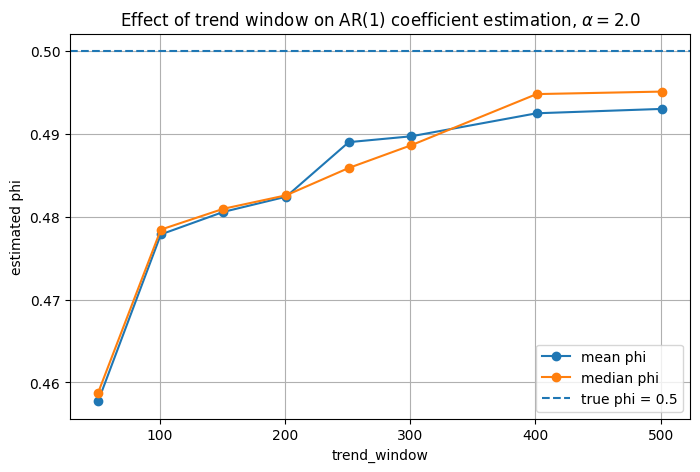

In [83]:
plt.figure(figsize=(8, 5))
plt.plot(phi_trend_test_alpha2["trend_window"], phi_trend_test_alpha2["mean_phi_hat"], marker="o", label="mean phi")
plt.plot(phi_trend_test_alpha2["trend_window"], phi_trend_test_alpha2["median_phi_hat"], marker="o", label="median phi")
plt.axhline(0.5, linestyle="--", label="true phi = 0.5")
plt.xlabel("trend_window")
plt.ylabel("estimated phi")
plt.title(r"Effect of trend window on AR(1) coefficient estimation, $\alpha=2.0$")
plt.grid(True)
plt.legend()
plt.show()

In [84]:
phi_trend_test_alpha19 = run_phi_trend_window_test(
    alpha=1.9,
    trend_windows=(51, 101, 151, 201, 251, 301, 401, 501),
    scale_window=101,
    n_replications=30,
)

phi_trend_test_alpha19

,alpha,trend_window,scale_window,mean_phi_hat,median_phi_hat,std_phi_hat,mean_alpha_hat,median_alpha_hat
0,1.9,51,101,0.465934,0.464786,0.023424,1.914356,1.914509
1,1.9,101,101,0.482252,0.482418,0.024887,1.896398,1.895125
2,1.9,151,101,0.493342,0.492902,0.026096,1.901223,1.909018
3,1.9,201,101,0.493268,0.495600,0.023074,1.884492,1.879803
4,1.9,251,101,0.496301,0.498036,0.018286,1.920641,1.925162
5,1.9,301,101,0.497858,0.499473,0.016578,1.887447,1.877593
6,1.9,401,101,0.505511,0.511491,0.024926,1.901395,1.904967
7,1.9,501,101,0.500805,0.501015,0.016067,1.881349,1.885388


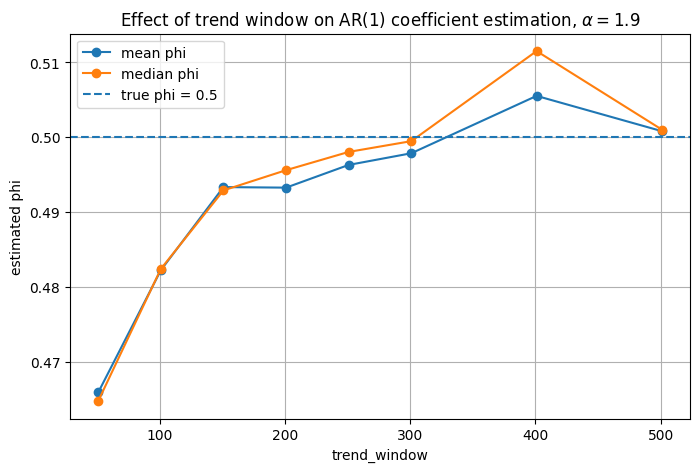

In [85]:
plt.figure(figsize=(8, 5))
plt.plot(phi_trend_test_alpha19["trend_window"], phi_trend_test_alpha19["mean_phi_hat"], marker="o", label="mean phi")
plt.plot(phi_trend_test_alpha19["trend_window"], phi_trend_test_alpha19["median_phi_hat"], marker="o", label="median phi")
plt.axhline(0.5, linestyle="--", label="true phi = 0.5")
plt.xlabel("trend_window")
plt.ylabel("estimated phi")
plt.title(r"Effect of trend window on AR(1) coefficient estimation, $\alpha=1.9$")
plt.grid(True)
plt.legend()
plt.show()

definitywnie wybieramy trend 501 a teraz jeszcze ktory scale

In [86]:
scale_after_trend501_alpha2 = run_phi_window_test(
    alpha=2.0,
    scale_windows=(101, 151, 201),
    trend_window=501,
    n_replications=30,
)

scale_after_trend501_alpha2

,alpha,trend_window,scale_window,mean_phi_hat,median_phi_hat,std_phi_hat,mean_alpha_hat,median_alpha_hat
0,2.0,501,101,0.494709,0.492403,0.019500,1.941363,1.954259
1,2.0,501,151,0.495054,0.494680,0.022843,1.973216,1.999878
2,2.0,501,201,0.496349,0.494298,0.021216,1.984068,2.000000


In [87]:
scale_after_trend501_alpha19 = run_phi_window_test(
    alpha=1.9,
    scale_windows=(101, 151, 201),
    trend_window=501,
    n_replications=30,
)

scale_after_trend501_alpha19

,alpha,trend_window,scale_window,mean_phi_hat,median_phi_hat,std_phi_hat,mean_alpha_hat,median_alpha_hat
0,1.9,501,101,0.505508,0.502156,0.020486,1.901312,1.915452
1,1.9,501,151,0.503268,0.503607,0.022068,1.920780,1.927823
2,1.9,501,201,0.498449,0.496122,0.025169,1.908795,1.920994


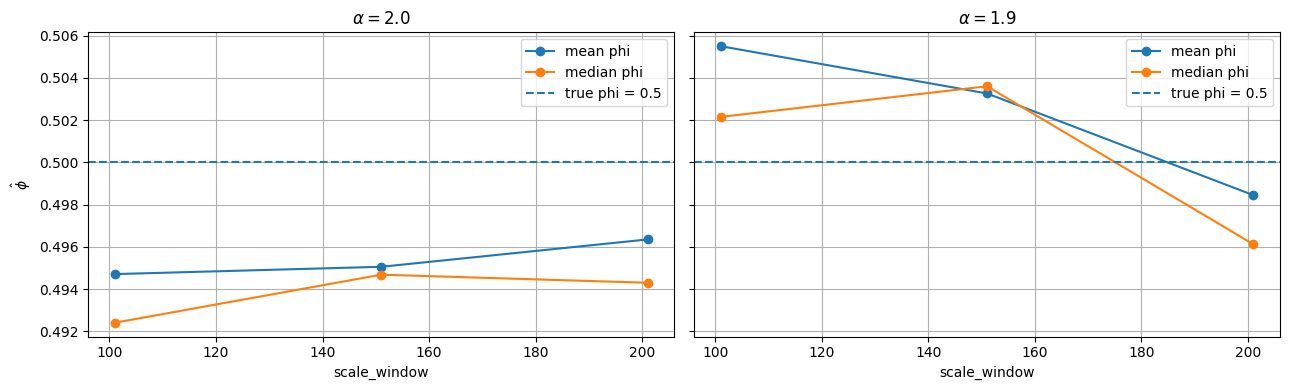

In [88]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)

axes[0].plot(scale_after_trend501_alpha2["scale_window"],
             scale_after_trend501_alpha2["mean_phi_hat"],
             marker="o", label="mean phi")
axes[0].plot(scale_after_trend501_alpha2["scale_window"],
             scale_after_trend501_alpha2["median_phi_hat"],
             marker="o", label="median phi")
axes[0].axhline(0.5, linestyle="--", label="true phi = 0.5")
axes[0].set_title(r"$\alpha=2.0$")
axes[0].set_xlabel("scale_window")
axes[0].set_ylabel(r"$\hat{\phi}$")
axes[0].grid(True)
axes[0].legend()

axes[1].plot(scale_after_trend501_alpha19["scale_window"],
             scale_after_trend501_alpha19["mean_phi_hat"],
             marker="o", label="mean phi")
axes[1].plot(scale_after_trend501_alpha19["scale_window"],
             scale_after_trend501_alpha19["median_phi_hat"],
             marker="o", label="median phi")
axes[1].axhline(0.5, linestyle="--", label="true phi = 0.5")
axes[1].set_title(r"$\alpha=1.9$")
axes[1].set_xlabel("scale_window")
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
plt.show()